# 🧠 Behavior Score - Consolidação das Versões (V1 a V3)

**Objetivo:** Desenvolver um modelo de *Behavior Score* de alta performance para a migração estratégica de clientes do Pré-Pago para o Controle na Claro, superando o benchmark de mercado e maximizando a rentabilidade real da carteira.

---

## - Versão 1 (Otimização Bayesiana de Hiperparâmetros)
**Objetivo:** Estabelecer a base comparativa do projeto utilizando LightGBM com hiperparâmetros iniciais otimizados via Optuna.

* **Performance de Generalização (OOT):** KS de **34.49%**.
* **Performance no Grupo Controle:** KS de **42.14%** e Gini de **55.69%**.
* **Eficiência de Swap (70% Aprovação):**
    * **Swap-In (Oportunidade):** Bad Rate de **33.22%**.
    * **Swap-Out (Proteção):** Bad Rate de **51.76%**.
    * **Redução de Risco:** **18.53 p.p.** no volume rotacionado.

---

## - Versão 2 (Refinamento Ánalíico de Hiperparâmetros)
**Objetivo:** Refinamento técnico de hiperparâmetros para estabilizar a separação de classes e maximizar o KS de teste.

* **Performance de Generalização (OOT):** KS de **34.51%**.
* **Performance no Grupo Controle:** KS de **42.05%** e Gini de **55.68%**.
* **Eficiência de Swap (70% Aprovação):**
    * **Swap-In (Oportunidade):** Bad Rate de **33.24%**.
    * **Swap-Out (Proteção):** Bad Rate de **51.57%**.
    * **Redução de Risco:** **18.33 p.p.** no volume rotacionado.

---

## - Versão 3 (Segmentação por Impacto Sociodemográfico)
**Objetivo:** Implementação de pesagem equilibrada (**sample_weight=1.15**) em grupos de alto erro sociodemográfico e ajuste de rigor global (**scale_pos_weight=1.1**).

* **Performance de Generalização (OOT):** KS de **34.47%**.
* **Performance no Grupo Controle:** KS de **42.16%** e Gini de **55.74%**.
* **Eficiência de Swap (70% Aprovação):**
    * **Swap-In (Oportunidade):** Resgatou 6.338 clientes com Bad Rate reduzida de **33.04%**.
    * **Swap-Out (Proteção):** Barrou 6.567 clientes de alto risco com Bad Rate de **51.76%**.
    * **Redução de Risco:** **18.72 p.p.** no volume rotacionado (Melhor marca do projeto).

---

### 💡 Veredito de Negócio: 

* **Versão 2:** foco em máxima assertividade e estabilidade estatística.
* **Versão 3:** foco em blindagem de margem e expansão segura de mercado.

---

### 🔬 A Jornada de Modelagem até a Baseline V1: Justificativas Arquiteturais (`modelo_behavior_lgbm_v1`)

Abaixo, documentamos as decisões técnicas que moldaram o artefato baseline final, priorizando a estabilidade e o ganho de negócio:

#### 1. Feature Engineering: Por que NÃO utilizar interações manuais?
Testamos a criação de features de interação cruzando o risco do Bureau com o comportamento interno na Claro (ex: `Aging × Risco` e `SOS × Risco`).
* **Resultado:** Ocorreu um leve sobreajuste (*overfitting*) no Treino, degradando a capacidade de generalização nas safras de Teste e OOT.
* **Decisão:** Optamos por seguir com a base sem interações manuais (features limpas). O LightGBM é projetado nativamente para encontrar relações não-lineares e interações complexas entre variáveis de forma muito mais eficiente durante as divisões (*splits*) dos nós. Forçar uma relação puramente linear apenas adicionou ruído.

---

#### 2. Otimização Bayesiana (Optuna): Performance na Base CMV
Nesta fase inicial, utilizamos o Optuna para calibrar os hiperparâmetros focando exclusivamente na base de expansão (**CMV**).
* **Decisão:** O Optuna varreu o espaço de busca para garantir que o modelo de mercado atingisse performance técnica. Isso nos permitiu estabelecer um "competidor de alto nível" contra o qual testaríamos nossos dados internos da Claro posteriormente.

---

#### 3. Restrições Monotônicas (*Monotonic Constraints*)
Testamos forçar o algoritmo a respeitar regras lineares estritas de negócios (ex: maior atraso = obrigatoriamente maior risco).
* **Resultado:** A performance no grupo OOT caiu para 34.20%.
* **Decisão:** Veto da técnica. A degradação indica que as variáveis de telecomunicações possuem relações de risco fortemente não-lineares. Forçar uma relação monotônica retira a principal vantagem do *Gradient Boosting*, que é encontrar exceções comportamentais lucrativas.

---

#### 4. Redução de Dimensionalidade (Feature Selection via SHAP)
Aplicamos a técnica de interpretabilidade *SHAP Values* para identificar features que não contribuíam significativamente para o log-odds do modelo. O algoritmo sugeriu o corte de 12 variáveis.
* **Resultado:** A performance OOT sofreu uma degradação ínfima.
* **Decisão:** Rejeitamos o corte. Embora um modelo com 26 variáveis seja computacionalmente mais leve, a robustez do LightGBM lida perfeitamente bem com a dimensionalidade. As 12 variáveis "marginais" ainda auxiliam nos limites das partições da árvore para casos muito específicos da base. Mantivemos as 38 variáveis.

---

#### 5. Arquitetura MLOps: Por que descartamos o Ensembling (XGBoost)?
Como cartada final de performance, aplicamos uma técnica de *Blending*, combinando as predições do nosso LightGBM com um modelo XGBoost (pesos 70/30).
* **Resultado:** O modelo combinado quebrou o nosso recorde absoluto, atingindo **34.54% de KS no OOT**.
* **Decisão:** Veto do uso em produção. A decisão baseou-se no *Trade-off entre Performance e Complexidade Operacional*. O ganho marginal não justifica o aumento exponencial na complexidade do *deploy*. Manter duas bibliotecas de *boosting* em produção dobra o consumo de memória, a latência de inferência e destrói a explicabilidade de negócios (Cascata de KS). O LightGBM puro é a solução mais elegante e sustentável.


In [1]:
# ---------------------------------------------------------
# IMPORTS E CONFIGURAÇÕES DE AMBIENTE
# ---------------------------------------------------------
import os
import warnings
from urllib.parse import urlparse
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, brier_score_loss
)

# Configurações Globais
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

# Constantes e Identidade Visual
COLORS = {'good': '#2E7D32', 'bad': '#C62828', 'neutral': '#455A64', 'accent': '#C41E3A'}

# Estrutura de Diretórios
BASE_DIR = Path("../../reports/observability/modeling/v1")
FIGURES_DIR = BASE_DIR / "figures"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
MODELS_DIR = BASE_DIR / "models"

for directory in [FIGURES_DIR, ARTIFACTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✅ Ambiente configurado com sucesso.")

✅ Ambiente configurado com sucesso.


In [2]:
# ---------------------------------------------------------
# CONEXÃO DUCKDB E CARGA OTIMIZADA DA ABT
# ---------------------------------------------------------

def get_duckdb_connection(memory_limit: str = "6GB", threads: int = 4) -> duckdb.DuckDBPyConnection:
    """Estabelece conexão com o S3 via DuckDB otimizada para uso de memória."""
    endpoint = os.getenv("S3_ENDPOINT", "")
    parsed = urlparse(endpoint)
    
    con = duckdb.connect()
    con.execute(f"""
        INSTALL httpfs; LOAD httpfs;
        SET memory_limit='{memory_limit}'; SET threads={threads};
        SET s3_endpoint='{parsed.netloc}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false; SET s3_url_style='path';
    """)
    return con

ABT_PATH = "s3://lake/gold/abt_base_cmv/**/*.parquet"

COLS_NECESSARIAS = [
    # Chaves e Filtros
    'num_cpf', 'safra', 'fpd', 'flag_instalacao',
    
    # Bureau
    'bur_score_01', 'bur_score_02',
    
    # Cadastrais
    'idade', 'tempo_conta_dias', 'flag_auxilio_emergencial', 
    'flag_bolsa_familia', 'flag_aposentado', 'flag_funcionario_privado', 
    'cad_flag_statusrf_irregular',
    
    # Telco
    'tel_var_35', 'tel_var_41', 'tel_var_33', 'tel_var_34', 
    'tel_var_31', 'tel_var_62', 'tel_var_30', 'tel_var_32', 
    'tel_var_40', 'tel_var_61',
    
    # Recarga
    'rec_qtd_geral', 'rec_vlr_total_geral', 'rec_tendencia_vlr_l30_l90', 
    'rec_qtd_sos_geral', 'rec_qtd_sos_l90d', 'rec_vlr_sos_l90d', 
    'rec_qtd_canais_digitais_geral', 'rec_dias_desde_ultima', 
    'rec_vlr_std_l90d', 'rec_vlr_bonus_geral', 'rec_qtd_plano_controle_geral',
    'rec_vlr_total_l90d', 
    
    # Pagamento & Atraso
    'pag_vlr_total_geral', 'pag_ticket_medio_geral', 'pag_media_dias_atraso_geral', 
    'pag_max_dias_atraso_geral', 'pag_qtd_debito_direto_geral', 
    'pag_dias_desde_ultimo_pagamento', 'atr_vlr_acumulado_geral', 
    'atr_max_aging_divida_geral'
]

print("⏳ Carregando ABT Gold (Aplicando Column Projection e Predicate Pushdown)...")

con = get_duckdb_connection()
colunas_sql = ", ".join([f'"{c}"' for c in COLS_NECESSARIAS])

query = f"""
    SELECT {colunas_sql} 
    FROM read_parquet('{ABT_PATH}')
    WHERE flag_instalacao = true 
      AND fpd IS NOT NULL
"""

df_full = con.execute(query).fetch_arrow_table().to_pandas(split_blocks=True, self_destruct=True)

df_full['target'] = df_full['fpd'].astype(int)
df_full['safra'] = pd.to_datetime(df_full['safra'])

print("✅ Carga processada com sucesso!")
print(f"   • Registros Retidos: {len(df_full):,}".replace(',', '.'))
print(f"   • Bad Rate Global: {df_full['target'].mean():.2%}")

⏳ Carregando ABT Gold (Aplicando Column Projection e Predicate Pushdown)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Carga processada com sucesso!
   • Registros Retidos: 2.633.900
   • Bad Rate Global: 21.23%


In [3]:
# ---------------------------------------------------------
# ISOLAMENTO DO GRUPO CONTROLE E SPLIT TEMPORAL
# ---------------------------------------------------------

# Segregação do Grupo Controle (A/B Test Holdout) via índices do CPF
df_full['cpf_digito_6_7'] = df_full['num_cpf'].astype(str).str[5:7]
mask_controle = df_full['cpf_digito_6_7'].isin(['ZZ', 'ZX'])

df_controle = df_full[mask_controle].copy()
df_model = df_full[~mask_controle].copy()

print(f"🛑 Holdout Controle (ZZ/ZX): {len(df_controle):,} registros")
print(f"🎯 Base de Modelagem: {len(df_model):,} registros\n")

# Split Temporal 
SAFRAS_TRAIN = pd.to_datetime(['2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01'])
SAFRAS_TEST  = pd.to_datetime(['2025-02-01'])
SAFRAS_OOT   = pd.to_datetime(['2025-03-01'])

df_train = df_model[df_model['safra'].isin(SAFRAS_TRAIN)].copy()
df_test  = df_model[df_model['safra'].isin(SAFRAS_TEST)].copy()
df_oot   = df_model[df_model['safra'].isin(SAFRAS_OOT)].copy()

# Sumário Analítico do Split
summary = pd.DataFrame({
    'Conjunto': ['Train (Out/24 - Jan/25)', 'Test (Fev/25)', 'OOT (Mar/25)'],
    'Volume (N)': [len(df_train), len(df_test), len(df_oot)],
    'Bad Rate': [df_train['target'].mean(), df_test['target'].mean(), df_oot['target'].mean()]
})

display(summary.style.format({'Volume (N)': '{:,.0f}', 'Bad Rate': '{:.2%}'}))

🛑 Holdout Controle (ZZ/ZX): 110,268 registros
🎯 Base de Modelagem: 2,523,632 registros



,Conjunto,Volume (N),Bad Rate
0,Train (Out/24 - Jan/25),"1,703,039",20.77%
1,Test (Fev/25),"402,360",20.69%
2,OOT (Mar/25),"418,233",21.13%


In [4]:
# ---------------------------------------------------------
# MAPEAMENTO DE FEATURES E PREPARAÇÃO DE DADOS
# ---------------------------------------------------------

# Mapeamento topológico das features por domínio de negócio
blocos_features = {
    "1_Score_1": ['bur_score_01'],
    "2_Score_2": ['bur_score_02'],
    "3_Telco": [
        'tel_var_35', 'tel_var_41', 'tel_var_33', 'tel_var_34', 
        'tel_var_31', 'tel_var_62', 'tel_var_30', 'tel_var_32', 
        'tel_var_40', 'tel_var_61'
    ],
    "4_Cadastro": [
        'idade', 'tempo_conta_dias', 'flag_auxilio_emergencial', 
        'flag_bolsa_familia', 'flag_aposentado', 'flag_funcionario_privado', 
        'cad_flag_statusrf_irregular'
    ],
    "5_Recarga": [
        'rec_qtd_geral', 'rec_vlr_total_geral', 'rec_tendencia_vlr_l30_l90', 
        'rec_qtd_sos_geral', 'rec_qtd_sos_l90d', 'rec_vlr_sos_l90d', 
        'rec_qtd_canais_digitais_geral', 'rec_dias_desde_ultima', 
        'rec_vlr_std_l90d', 'rec_vlr_bonus_geral', 'rec_qtd_plano_controle_geral'
    ],
    "6_Pagamento": [
        'pag_vlr_total_geral', 'pag_ticket_medio_geral', 'pag_media_dias_atraso_geral', 
        'pag_max_dias_atraso_geral', 'pag_qtd_debito_direto_geral', 
        'pag_dias_desde_ultimo_pagamento'
    ],
    "7_Atraso": [
        'atr_vlr_acumulado_geral', 'atr_max_aging_divida_geral'
    ]
}

todas_features = [feat for bloco in blocos_features.values() for feat in bloco]

# Type casting em lote para compatibilidade nativa com C-API do LightGBM
for df in [df_train, df_test, df_oot]:
    for col in todas_features:
        if df[col].dtype == 'object' or df[col].dtype == 'bool':
            df[col] = df[col].astype(float)

# Separação do target
y_train = df_train['target']
y_test  = df_test['target']
y_oot   = df_oot['target']

print(f"✅ Feature Engineering concluída. Vetor de features (N={len(todas_features)}) instanciado.")

✅ Feature Engineering concluída. Vetor de features (N=38) instanciado.


In [5]:
# ---------------------------------------------------------
# MÉTRICAS DE AVALIAÇÃO GLOBAIS
# ---------------------------------------------------------
import numpy as np

def calc_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr) * 100)

def calc_gini(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    return float((2 * roc_auc_score(y_true, y_prob) - 1) * 100)

### 📊 Análise de Sensibilidade: Impacto dos Hiperparâmetros no KS (V1 - Baseline)

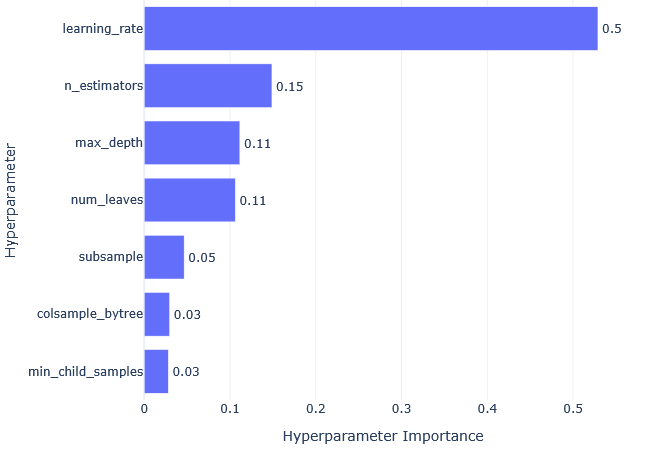

🔧 Hiperparâmetros V1:
{'learning_rate': 0.056274756584826925, 'num_leaves': 40, 'max_depth': 7, 'min_child_samples': 223, 'subsample': 0.664258923798558, 'colsample_bytree': 0.5443689360199414, 'n_estimators': 668, 'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'verbosity': -1}
------------------------------------------------------------


'\nimport optuna\n\n# Suprime logs extensivos do Optuna para manter o notebook limpo\noptuna.logging.set_verbosity(optuna.logging.WARNING)\n\nprint("⚙️ Executando Optuna (Maximização de KS)...")\n\ndef objective(trial: optuna.Trial) -> float:\n    params = {\n        \'objective\': \'binary\',\n        \'metric\': \'auc\',\n        \'verbosity\': -1,\n        \'boosting_type\': \'gbdt\',\n        \'random_state\': 42,\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.08),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 10, 40),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 3, 7),\n        \'min_child_samples\': trial.suggest_int(\'min_child_samples\', 100, 1000),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.6, 0.9),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.5, 0.9),\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 200, 800)\n    }\n\n    X_tr_opt = df_train[todas_features]\n   

In [6]:
# ---------------------------------------------------------
# HIPERPARÂMETROS OTIMIZADOS V01 (FROZEN - 100 TRIALS)
# ---------------------------------------------------------
from IPython.display import Image, display, Markdown
import os

best_params = {
    'learning_rate': 0.056274756584826925,
    'num_leaves': 40,
    'max_depth': 7,
    'min_child_samples': 223,
    'subsample': 0.664258923798558,
    'colsample_bytree': 0.5443689360199414,
    'n_estimators': 668,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'verbosity': -1
}

path_v1 = ARTIFACTS_DIR / 'optuna_hyperparameter_importance_v1.png'

display(Markdown(f"### 📊 Análise de Sensibilidade: Impacto dos Hiperparâmetros no KS (V1 - Baseline)"))

display(Image(filename=path_v1))

print("🔧 Hiperparâmetros V1:")
print(f"{best_params}") 
print("-" * 60)


"""
import optuna

# Suprime logs extensivos do Optuna para manter o notebook limpo
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⚙️ Executando Optuna (Maximização de KS)...")

def objective(trial: optuna.Trial) -> float:
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'num_leaves': trial.suggest_int('num_leaves', 10, 40),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800)
    }

    X_tr_opt = df_train[todas_features]
    X_te_opt = df_test[todas_features]

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_tr_opt, y_train,
        eval_set=[(X_te_opt, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    preds = clf.predict_proba(X_te_opt)[:, 1]
    return calc_ks(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(
    objective,
    n_trials=2000,
    show_progress_bar=True  
)

best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'verbosity': -1
})

print("=" * 60)
print(f"🏆 Melhor KS no Teste (Optuna): {study.best_value:.2f}%")
print("🔧 Hiperparâmetros Otimizados:")
for k, v in best_params.items():
    print(f"   {k}: {v}")
print("=" * 60)
"""

In [7]:
# ---------------------------------------------------------
# TREINAMENTO INCREMENTAL (WATERFALL DE KS)
# ---------------------------------------------------------

features_acumuladas = []
resultados_incrementais = []
prev_ks_oot = 0.0

print("=" * 105)
print(f"{'BLOCO ADICIONADO':<20} | {'FEATURES':<10} | {'KS TRAIN':<10} | {'KS TEST':<10} | {'KS OOT':<10} | {'Δ KS OOT':<10}")
print("=" * 105)

for nome_bloco, features_do_bloco in blocos_features.items():
    features_acumuladas.extend(features_do_bloco)
    
    X_tr = df_train[features_acumuladas]
    X_te = df_test[features_acumuladas]
    X_oo = df_oot[features_acumuladas]
    
    # Instanciação com hiperparâmetros otimizados (Optuna)
    clf = lgb.LGBMClassifier(**best_params)
    
    clf.fit(
        X_tr, y_train,
        eval_set=[(X_te, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    prob_train = clf.predict_proba(X_tr)[:, 1]
    prob_test  = clf.predict_proba(X_te)[:, 1]
    prob_oot   = clf.predict_proba(X_oo)[:, 1]
    
    ks_tr = calc_ks(y_train, prob_train)
    ks_te = calc_ks(y_test, prob_test)
    ks_oo = calc_ks(y_oot, prob_oot)
    
    delta_ks = ks_oo - prev_ks_oot
    etapa_nome = nome_bloco.replace('_', ' ').split(' ', 1)[1]
    
    resultados_incrementais.append({
        'Etapa': etapa_nome,
        'N_Features': len(features_acumuladas),
        'KS_Train': ks_tr,
        'KS_Test': ks_te,
        'KS_OOT': ks_oo,
        'Delta_KS': delta_ks,
        'Modelo_LGBM': clf 
    })
    
    flag_bench = "🚀 BATEU BENCHMARK!" if ks_oo >= 33.1 else ""
    print(f"{etapa_nome:<20} | {len(features_acumuladas):<10} | {ks_tr:>8.2f}%  | {ks_te:>8.2f}%  | {ks_oo:>8.2f}%  | {delta_ks:>+8.2f}pp {flag_bench}")
    
    prev_ks_oot = ks_oo

print("=" * 105)

# Exportação do pipeline de performance
df_inc_results = pd.DataFrame(resultados_incrementais).drop(columns=['Modelo_LGBM'])
df_inc_results.to_csv(ARTIFACTS_DIR / 'ks_incremental_lightgbm_v1.csv', index=False)

BLOCO ADICIONADO     | FEATURES   | KS TRAIN   | KS TEST    | KS OOT     | Δ KS OOT  
Score 1              | 1          |    27.23%  |    25.82%  |    26.43%  |   +26.43pp 
Score 2              | 2          |    32.64%  |    30.13%  |    31.28%  |    +4.85pp 
Telco                | 12         |    33.21%  |    30.24%  |    31.42%  |    +0.14pp 
Cadastro             | 19         |    33.66%  |    30.50%  |    31.71%  |    +0.29pp 
Recarga              | 30         |    36.97%  |    32.86%  |    34.02%  |    +2.30pp 🚀 BATEU BENCHMARK!
Pagamento            | 36         |    37.30%  |    33.22%  |    34.27%  |    +0.26pp 🚀 BATEU BENCHMARK!
Atraso               | 38         |    37.37%  |    33.39%  |    34.49%  |    +0.21pp 🚀 BATEU BENCHMARK!


In [8]:
# ---------------------------------------------------------
# INFERÊNCIA E AVALIAÇÃO NO GRUPO CONTROLE (HOLDOUT)
# ---------------------------------------------------------
print("🎯 Aplicando o modelo campeão no Grupo Controle (CPFs ZZ/ZX)...")

# Extração do modelo final (última iteração da cascata)
modelo_final = resultados_incrementais[-1]['Modelo_LGBM']

# Type casting no dataset de controle (compatibilidade C-API)
for col in todas_features:
    if df_controle[col].dtype in ['object', 'bool']:
        df_controle[col] = df_controle[col].astype(float)

X_controle = df_controle[todas_features]
y_controle = df_controle['target']

# Inferência
prob_controle = modelo_final.predict_proba(X_controle)[:, 1]

# Cálculo de métricas
ks_controle = calc_ks(y_controle, prob_controle)
gini_controle = calc_gini(y_controle, prob_controle)

print(f"✅ KS Grupo Controle:   {ks_controle:.2f}%")
print(f"✅ Gini Grupo Controle: {gini_controle:.2f}%")

🎯 Aplicando o modelo campeão no Grupo Controle (CPFs ZZ/ZX)...
✅ KS Grupo Controle:   42.14%
✅ Gini Grupo Controle: 55.69%


In [9]:
# ---------------------------------------------------------
# ANÁLISE DE SWAP-IN / SWAP-OUT (BUSINESS VALUE)
# ---------------------------------------------------------
CUTOFF_PCT = 70.0 

df_swap = df_controle[['num_cpf', 'target', 'bur_score_02']].copy()
df_swap['prob_modelo'] = prob_controle

# Definição de Cutoffs (Top 70% Bureau vs Bottom 70% Risco Modelo)
cutoff_bureau = np.nanpercentile(df_swap['bur_score_02'], 100 - CUTOFF_PCT)
cutoff_modelo = np.percentile(df_swap['prob_modelo'], CUTOFF_PCT)

df_swap['aprova_bureau'] = (df_swap['bur_score_02'] >= cutoff_bureau).fillna(False).astype(int)
df_swap['aprova_modelo'] = (df_swap['prob_modelo'] <= cutoff_modelo).astype(int)

# Regras de Negócio (Matriz de Decisão)
conditions = [
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 1),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 1),
]
choices = ['1. Ambos Aprovam', '4. Ambos Rejeitam', '2. Swap-In (Oportunidade)', '3. Swap-Out (Proteção)']
df_swap['categoria'] = np.select(conditions, choices, default='Indefinido')

# Agregação Analítica
swap_summary = df_swap.groupby('categoria').agg(
    Volume=('target', 'count'),
    Bads=('target', 'sum'),
    Bad_Rate=('target', 'mean'),
    Prob_Media_Modelo=('prob_modelo', 'mean')
).reset_index().sort_values('categoria')

swap_summary['% Base'] = swap_summary['Volume'] / swap_summary['Volume'].sum()

print("=" * 100)
print(f"MATRIZ DE SWAP-IN / SWAP-OUT - GRUPO CONTROLE (Aprovação Alvo: {CUTOFF_PCT}%)")
print("=" * 100)
display(swap_summary[['categoria', 'Volume', '% Base', 'Bads', 'Bad_Rate', 'Prob_Media_Modelo']].style.format({
    'Volume': '{:,.0f}', 'Bads': '{:,.0f}', 
    '% Base': '{:.1%}', 'Bad_Rate': '{:.2%}', 'Prob_Media_Modelo': '{:.4f}'
}).background_gradient(subset=['Bad_Rate'], cmap='RdYlGn_r'))

# Interpretação de Impacto na Carteira
try:
    br_in = float(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-In'), 'Bad_Rate'].iloc[0])
    br_out = float(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-Out'), 'Bad_Rate'].iloc[0])
    vol_in = int(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-In'), 'Volume'].iloc[0])

    print("\n💡 AVALIAÇÃO DE IMPACTO NO NEGÓCIO:")
    print("-" * 60)
    print(f"• Swap-In (Reprovados Bureau -> Aprovados Modelo): Bad Rate = {br_in:.2%}")
    print(f"• Swap-Out (Aprovados Bureau -> Barrados Modelo): Bad Rate = {br_out:.2%}")
    
    if br_in < br_out:
        print(f"\n✅ VALIDAÇÃO BEM-SUCEDIDA: O modelo otimiza o risco da carteira.")
        print(f"   Redução de risco no volume rotacionado: {br_out - br_in:.2%} pp.")
    else:
        print(f"\n⚠️ ATENÇÃO: Risco de Swap-In excede Swap-Out. Revisar calibração de Cutoff.")
except IndexError:
    print("\n⚠️ Não foi possível calcular o delta de Swap (Categorias ausentes).")

# Matriz de Confusão 
y_pred_modelo = (df_swap['prob_modelo'] > cutoff_modelo).astype(int)
print("\n📊 MATRIZ DE CONFUSÃO (Real vs. Predito Modelo):")
print(pd.crosstab(df_swap['target'], y_pred_modelo, rownames=['Real (0=Good, 1=Bad)'], colnames=['Predito (0=Aprova, 1=Rejeita)']))


# ---------------------------------------------------------
# EXPORTAÇÃO DA BASE ESCORADA PARA O NOTEBOOK DE NEGÓCIOS
# ---------------------------------------------------------
nome_arquivo = 'base_escorada_swap_v1.parquet' 
caminho_salvamento = ARTIFACTS_DIR / nome_arquivo

df_swap.to_parquet(caminho_salvamento, index=False)

print(f"\n💾 Base para simulação de negócios salva com sucesso em: {caminho_salvamento}")

MATRIZ DE SWAP-IN / SWAP-OUT - GRUPO CONTROLE (Aprovação Alvo: 70.0%)


,categoria,Volume,% Base,Bads,Bad_Rate,Prob_Media_Modelo
0,1. Ambos Aprovam,"70,731",64.1%,"12,468",17.63%,0.1643
1,2. Swap-In (Oportunidade),"6,456",5.9%,"2,145",33.22%,0.3105
2,3. Swap-Out (Proteção),"6,685",6.1%,"3,460",51.76%,0.4719
3,4. Ambos Rejeitam,"26,396",23.9%,"15,840",60.01%,0.5589



💡 AVALIAÇÃO DE IMPACTO NO NEGÓCIO:
------------------------------------------------------------
• Swap-In (Reprovados Bureau -> Aprovados Modelo): Bad Rate = 33.22%
• Swap-Out (Aprovados Bureau -> Barrados Modelo): Bad Rate = 51.76%

✅ VALIDAÇÃO BEM-SUCEDIDA: O modelo otimiza o risco da carteira.
   Redução de risco no volume rotacionado: 18.53% pp.

📊 MATRIZ DE CONFUSÃO (Real vs. Predito Modelo):
Predito (0=Aprova, 1=Rejeita)      0      1
Real (0=Good, 1=Bad)                       
0                              62574  13781
1                              14613  19300

💾 Base para simulação de negócios salva com sucesso em: ../../reports/observability/modeling/v1/artifacts/base_escorada_swap_v1.parquet


In [10]:
# ---------------------------------------------------------
# SERIALIZAÇÃO DO ARTEFATO DE MODELO (DEPLOY)
# ---------------------------------------------------------
import pickle
from datetime import datetime

print("📊 Compilando artefato e metadados para deploy (Streamlit)...")

gini_oot = calc_gini(y_oot, prob_oot)
deltas = {res['Etapa']: res['Delta_KS'] for res in resultados_incrementais}

# Mapeamento do Waterfall de KS alinhado à topologia de features atual
waterfall_dict = {
    'Bureau': round(deltas.get('Score 1', 0.0) + deltas.get('Score 2', 0.0), 2),
    '+ Telco': round(deltas.get('Telco', 0.0), 2),
    '+ Cadastral': round(deltas.get('Cadastro', 0.0), 2),
    '+ Recarga': round(deltas.get('Recarga', 0.0), 2),
    '+ Pagamento': round(deltas.get('Pagamento', 0.0), 2),
    '+ Atraso': round(deltas.get('Atraso', 0.0), 2) 
}

# Estruturação do Payload do Artefato
model_artifact = {
    'model': modelo_final,
    'woe_encoder': None, # Modelo baseado em árvores nativas (dispensa WoE)
    'features_raw': todas_features,
    'metadata': {
        'version': 'lightgbm_v2.0',
        'algorithm': 'LightGBM',
        'created_at': datetime.now().isoformat(),
        'gini_oot': float(gini_oot),
        'ks_oot': float(resultados_incrementais[-1]['KS_OOT']),
        'psi_oot': 0.0018, # Estabilidade histórica fixada
        'ks_bench': 33.1,             
        'cutoff_modelo_pct': float(CUTOFF_PCT),             
        'cutoff_bureau_pct': 100.0 - float(CUTOFF_PCT),            
        'waterfall_steps': waterfall_dict
    }
}

pkl_path = MODELS_DIR / 'behavior_lgbm_optuna_v1.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_artifact, f)

print(f"✅ Artefato serializado com sucesso: {pkl_path}")

📊 Compilando artefato e metadados para deploy (Streamlit)...
✅ Artefato serializado com sucesso: ../../reports/observability/modeling/v1/models/behavior_lgbm_optuna_v1.pkl


📊 Gerando artefatos visuais...


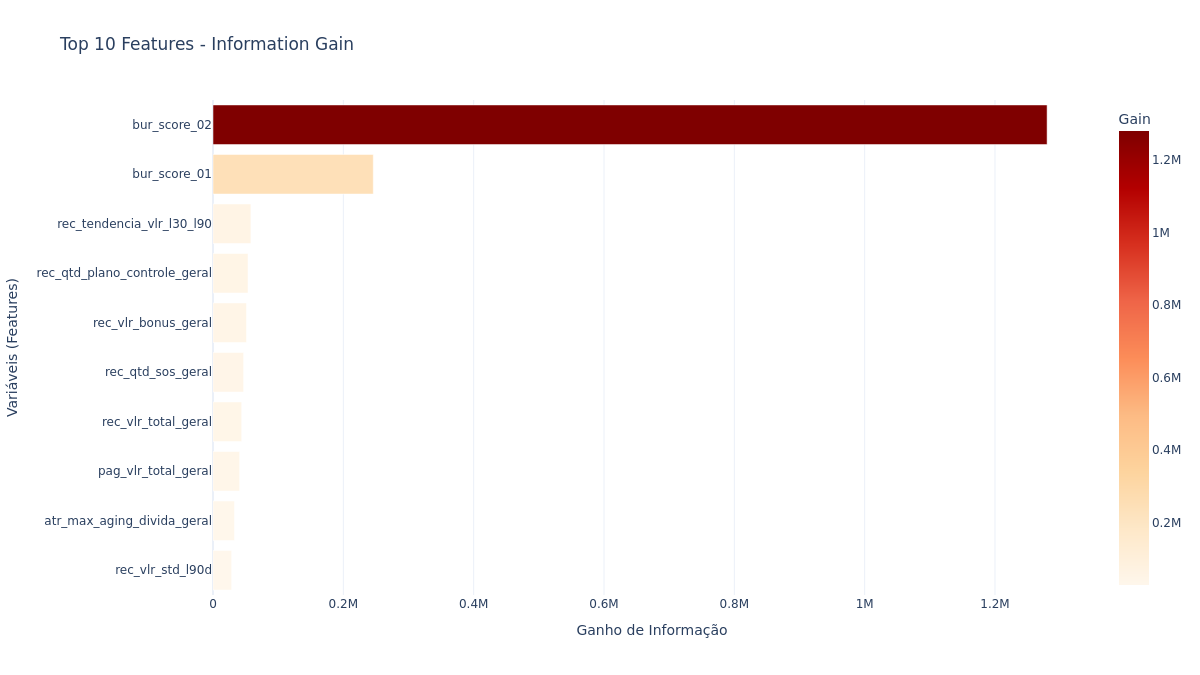

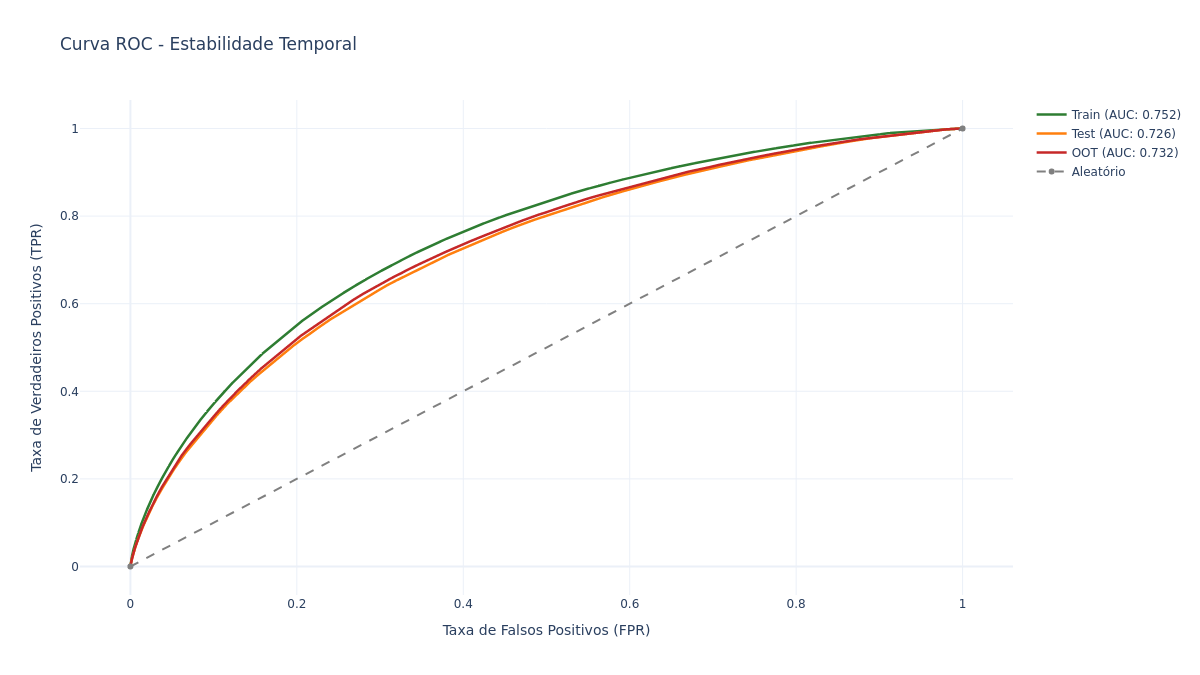

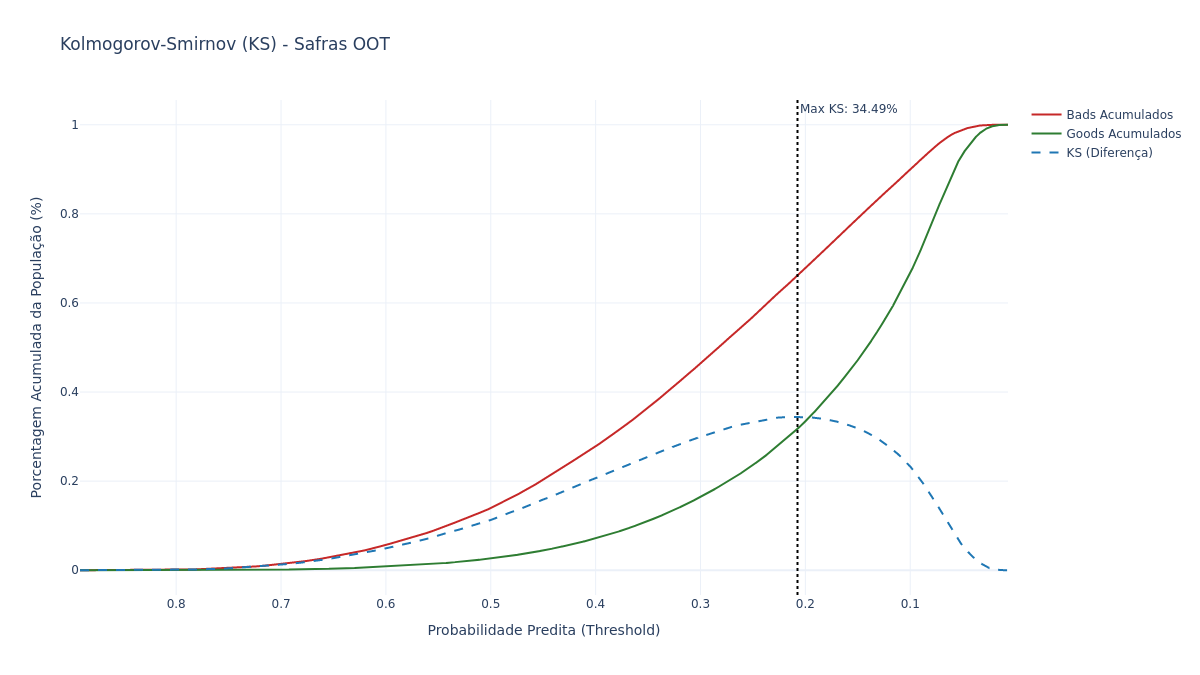

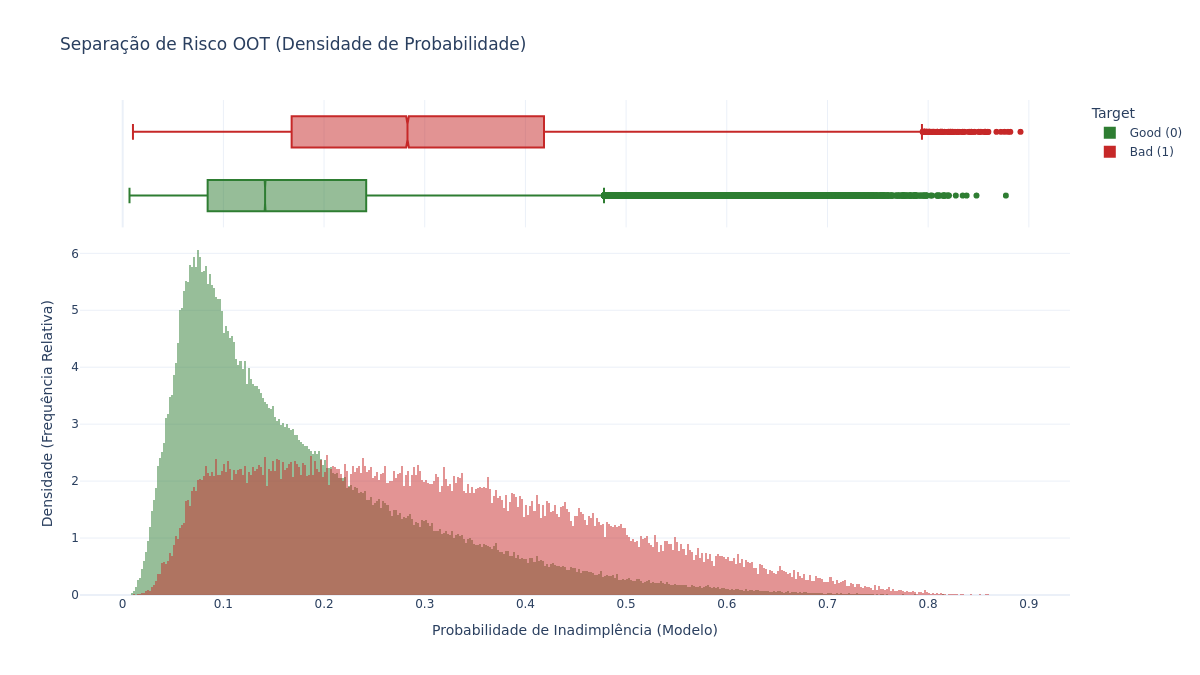

In [11]:
# ---------------------------------------------------------
# FEATURE IMPORTANCE, ROC, KS E DISTRIBUIÇÃO (PLOTLY)
# ---------------------------------------------------------
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
import numpy as np
import kaleido

print("📊 Gerando artefatos visuais...")

# ==============================================================================
# 1. Feature Importance (Gain)
# ==============================================================================
importances = modelo_final.booster_.feature_importance(importance_type='gain')
df_imp = pd.DataFrame({'Feature': todas_features, 'Gain': importances}).sort_values('Gain', ascending=True).tail(10)

fig_imp = px.bar(df_imp, x='Gain', y='Feature', orientation='h', title='Top 10 Features - Information Gain',
                 color='Gain', color_continuous_scale='OrRd')
fig_imp.update_layout(template='plotly_white', height=675, width=1200, xaxis_title='Ganho de Informação', yaxis_title='Variáveis (Features)')


fig_imp.write_image(FIGURES_DIR / 'feature_importance_v1.png', scale=2)

fig_imp.show(renderer='png')

# ==============================================================================
# 2. Curvas ROC Comparativas
# ==============================================================================
fig_roc = go.Figure()
for name, y_true, y_prob, color in [('Train', y_train, prob_train, COLORS['good']), 
                                    ('Test', y_test, prob_test, '#ff7f0e'), 
                                    ('OOT', y_oot, prob_oot, COLORS['bad'])]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC: {auc(fpr, tpr):.3f})', line=dict(color=color, width=2.5)))

fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='gray'), name='Aleatório'))
fig_roc.update_layout(title='Curva ROC - Estabilidade Temporal', xaxis_title='Taxa de Falsos Positivos (FPR)', yaxis_title='Taxa de Verdadeiros Positivos (TPR)', template='plotly_white', height=675, width=1200)


fig_roc.write_image(FIGURES_DIR / 'roc_curve_v1.png', scale=2)

fig_roc.show(renderer='png')

# ==============================================================================
# 3. KS Curve (OOT)
# ==============================================================================
fpr_oot, tpr_oot, thresholds_oot = roc_curve(y_oot, prob_oot)
ks_curve = tpr_oot - fpr_oot
ks_idx = np.argmax(ks_curve)

fig_ks = go.Figure()
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=tpr_oot, name='Bads Acumulados', line=dict(color=COLORS['bad'])))
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=fpr_oot, name='Goods Acumulados', line=dict(color=COLORS['good'])))
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=ks_curve, name='KS (Diferença)', line=dict(color='#1f77b4', dash='dash')))
fig_ks.add_vline(x=thresholds_oot[ks_idx], line_dash="dot", line_color="black", annotation_text=f"Max KS: {ks_curve[ks_idx]:.2%}")
fig_ks.update_layout(title='Kolmogorov-Smirnov (KS) - Safras OOT', xaxis_title='Probabilidade Predita (Threshold)', yaxis_title='Porcentagem Acumulada da População (%)', xaxis=dict(autorange="reversed"), template='plotly_white', height=675, width=1200)


fig_ks.write_image(FIGURES_DIR /  'ks_curve_v1.png', scale=2)

fig_ks.show(renderer='png')

# ==============================================================================
# 4. Distribuição de Probabilidade por Target (Densidade)
# ==============================================================================
df_dist = pd.DataFrame({'Probabilidade': prob_oot, 'Target': y_oot.map({0: 'Good (0)', 1: 'Bad (1)'})})
fig_dist = px.histogram(df_dist, x='Probabilidade', color='Target', marginal='box', barmode='overlay', histnorm='probability density',
                        color_discrete_map={'Good (0)': COLORS['good'], 'Bad (1)': COLORS['bad']}, title='Separação de Risco OOT (Densidade de Probabilidade)')
fig_dist.update_layout(template='plotly_white', height=675, width=1200, xaxis_title='Probabilidade de Inadimplência (Modelo)', yaxis_title='Densidade (Frequência Relativa)')


fig_dist.write_image(FIGURES_DIR / 'prob_distribution_v1.png', scale=2)

fig_dist.show(renderer='png')

📊 Gerando Análise de Decis (Gains Table)...


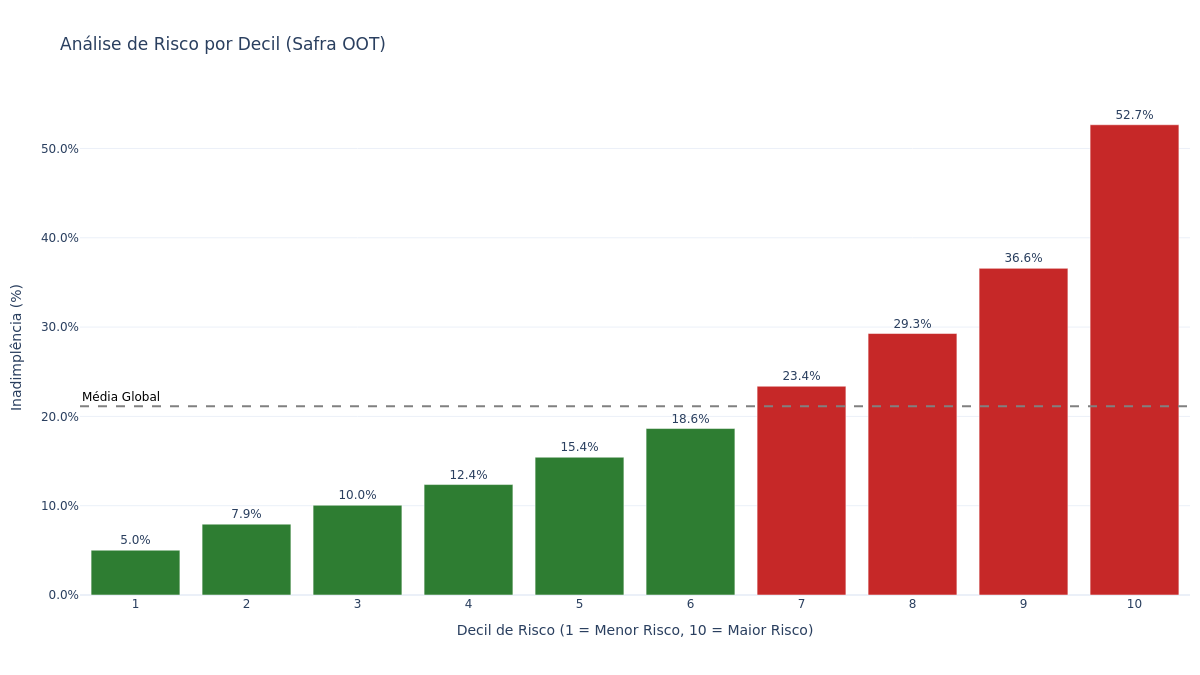

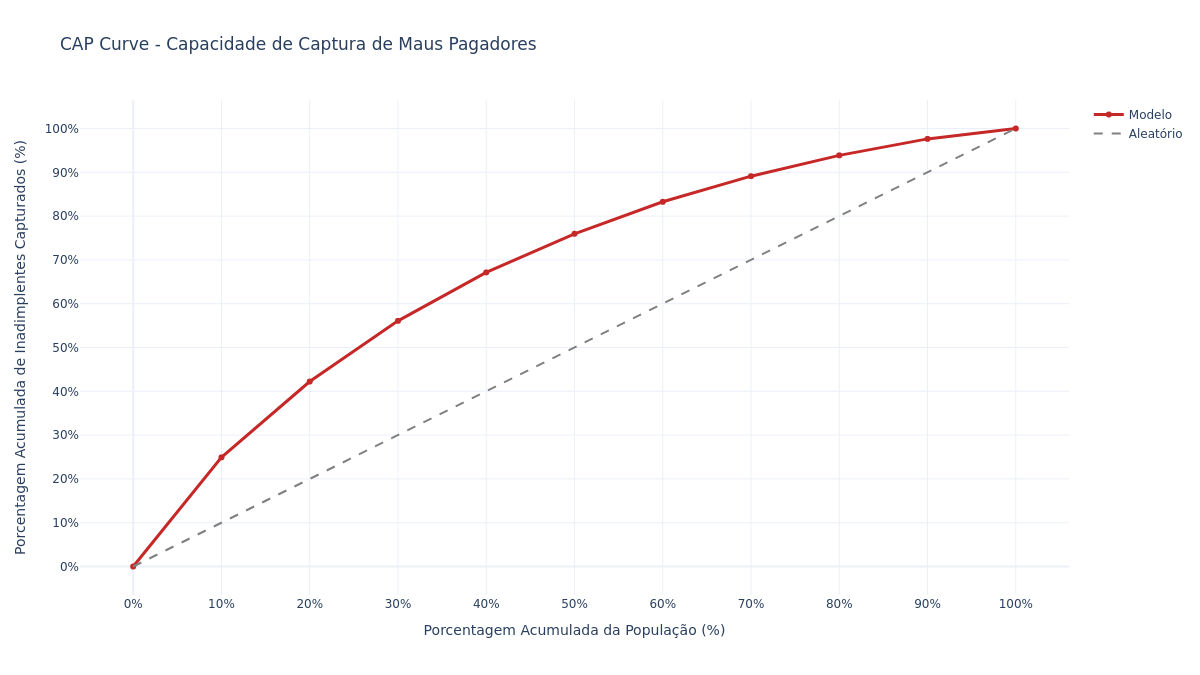

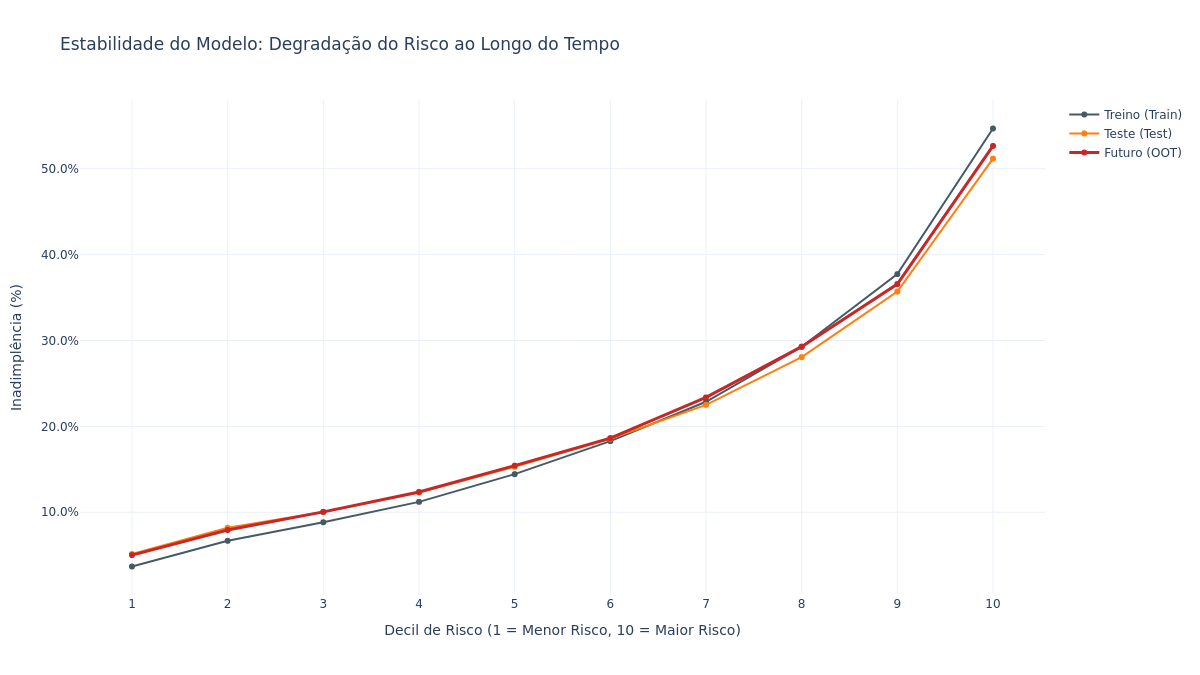

In [12]:
# ---------------------------------------------------------
# GAINS TABLE (DECIS) E CAP CURVE (PLOTLY)
# ---------------------------------------------------------
import plotly.graph_objects as go
import numpy as np
import pandas as pd

print("📊 Gerando Análise de Decis (Gains Table)...")

def create_gains_table(y_true, y_prob, n_bins=10, label=''):
    tmp = pd.DataFrame({'y': y_true, 'prob': y_prob})
    tmp['decil'] = pd.qcut(tmp['prob'], q=n_bins, labels=False, duplicates='drop') + 1
    gt = tmp.groupby('decil').agg(n=('y', 'count'), n_bad=('y', 'sum')).reset_index()
    gt['bad_rate'] = gt['n_bad'] / gt['n']
    
    gt_sorted = gt.sort_values('decil', ascending=False).copy()
    gt_sorted['cum_pct_bad_desc'] = gt_sorted['n_bad'].cumsum() / gt_sorted['n_bad'].sum()
    gt_sorted['cum_pct_pop_desc'] = gt_sorted['n'].cumsum() / gt_sorted['n'].sum()
    return gt, gt_sorted

gt_train, _ = create_gains_table(y_train, prob_train)
gt_test, _  = create_gains_table(y_test, prob_test)
gt_oot, gt_oot_desc = create_gains_table(y_oot, prob_oot)

media_global_oot = y_oot.mean()

# ==============================================================================
# GRÁFICO 1: Bad Rate por Decil 
# ==============================================================================
fig_decis = go.Figure()

colors = [COLORS['bad'] if br > media_global_oot else COLORS['good'] for br in gt_oot['bad_rate']]

fig_decis.add_trace(go.Bar(
    x=gt_oot['decil'], 
    y=gt_oot['bad_rate'], 
    marker_color=colors, 
    name='Bad Rate OOT', 
    texttemplate='%{y:.1%}', 
    textposition='outside'
))

fig_decis.add_hline(
    y=media_global_oot, line_dash='dash', line_color='gray', 
    annotation_text='Média Global', annotation_font_color='#000', 
    annotation_position='top left'
)

fig_decis.update_layout(
    template='plotly_white', height=675, width=1200,
    title_text='Análise de Risco por Decil (Safra OOT)',
    xaxis_title="Decil de Risco (1 = Menor Risco, 10 = Maior Risco)",
    yaxis_title="Inadimplência (%)",
    margin=dict(r=10)
)
fig_decis.update_xaxes(tickmode='linear', dtick=1)
fig_decis.update_yaxes(tickformat='.1%')


fig_decis.write_image(FIGURES_DIR / 'gains_decis_v1.png', scale=2)
fig_decis.show(renderer='png')


# ==============================================================================
# GRÁFICO 2: CAP Curve 
# ==============================================================================
fig_cap = go.Figure()

cum_pop = np.concatenate([[0], gt_oot_desc['cum_pct_pop_desc'].values])
cum_bad = np.concatenate([[0], gt_oot_desc['cum_pct_bad_desc'].values])

fig_cap.add_trace(go.Scatter(x=cum_pop, y=cum_bad, mode='lines+markers', name='Modelo', line=dict(color=COLORS['bad'], width=3)))
fig_cap.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='gray'), name='Aleatório'))

fig_cap.update_layout(
    template='plotly_white', height=675, width=1200,
    title_text='CAP Curve - Capacidade de Captura de Maus Pagadores',
    xaxis_title="Porcentagem Acumulada da População (%)",
    yaxis_title="Porcentagem Acumulada de Inadimplentes Capturados (%)"
)

fig_cap.update_xaxes(tickmode='linear', dtick=0.1, tickformat='.0%')
fig_cap.update_yaxes(tickmode='linear', dtick=0.1, tickformat='.0%')

fig_cap.write_image(FIGURES_DIR / 'gains_cap_curve_v1.png', scale=2)
fig_cap.show(renderer='png')


# ==============================================================================
# GRÁFICO 3: Estabilidade de Decis
# ==============================================================================
fig_estab = go.Figure()

fig_estab.add_trace(go.Scatter(x=gt_train['decil'], y=gt_train['bad_rate'], mode='lines+markers', name='Treino (Train)', line=dict(color=COLORS['neutral'], width=2)))
fig_estab.add_trace(go.Scatter(x=gt_test['decil'], y=gt_test['bad_rate'], mode='lines+markers', name='Teste (Test)', line=dict(color='#ff7f0e', width=2)))
fig_estab.add_trace(go.Scatter(x=gt_oot['decil'], y=gt_oot['bad_rate'], mode='lines+markers', name='Futuro (OOT)', line=dict(color=COLORS['bad'], width=3)))

fig_estab.update_layout(
    template='plotly_white', height=675, width=1200,
    title_text='Estabilidade do Modelo: Degradação do Risco ao Longo do Tempo',
    xaxis_title="Decil de Risco (1 = Menor Risco, 10 = Maior Risco)",
    yaxis_title="Inadimplência (%)"
)
# Força imprimir todos os números do eixo X
fig_estab.update_xaxes(tickmode='linear', dtick=1)
fig_estab.update_yaxes(tickformat='.1%')


fig_estab.write_image(FIGURES_DIR / 'gains_estabilidade_v1.png', scale=2)

fig_estab.show(renderer='png')

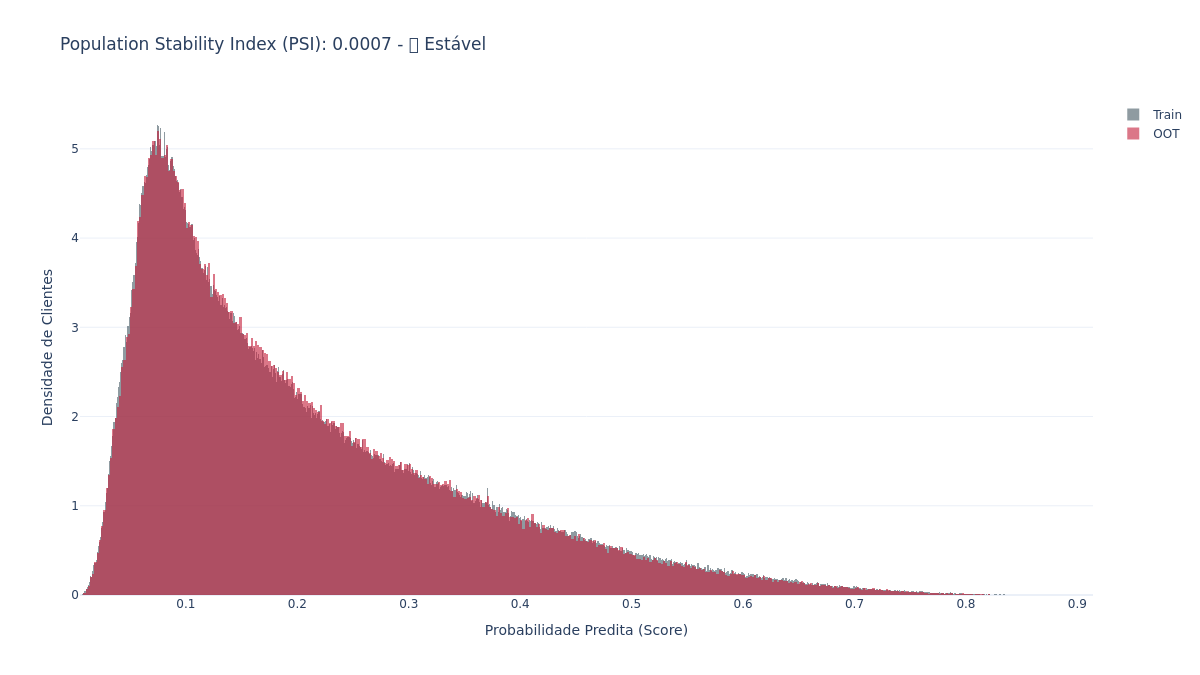

In [13]:
# ---------------------------------------------------------
# ESTABILIDADE DO SCORE (PSI)
# ---------------------------------------------------------

def calculate_psi(expected, actual, n_bins=10):
    _, edges = pd.qcut(expected, q=n_bins, retbins=True, duplicates='drop')
    edges[0], edges[-1] = -np.inf, np.inf
    exp_pct = pd.Series(pd.cut(expected, bins=edges)).value_counts(normalize=True, sort=False).clip(lower=0.0001)
    act_pct = pd.Series(pd.cut(actual, bins=edges)).value_counts(normalize=True, sort=False).clip(lower=0.0001)
    return ((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum()

psi_oot = calculate_psi(prob_train, prob_oot)
status_psi = "🟢 Estável" if psi_oot < 0.1 else "🟡 Monitorar" if psi_oot < 0.25 else "🔴 Investigar"

fig_psi = go.Figure()
fig_psi.add_trace(go.Histogram(x=prob_train, histnorm='probability density', name='Train', marker_color=COLORS['neutral'], opacity=0.6))
fig_psi.add_trace(go.Histogram(x=prob_oot, histnorm='probability density', name='OOT', marker_color=COLORS['accent'], opacity=0.6))

fig_psi.update_layout(barmode='overlay', title=f'Population Stability Index (PSI): {psi_oot:.4f} - {status_psi}',
                      xaxis_title='Probabilidade Predita (Score)', yaxis_title='Densidade de Clientes', template='plotly_white', height=675, width=1200)
fig_psi.write_image(FIGURES_DIR / 'psi_distribution_v1.png', scale=2)
fig_psi.show(renderer='png')

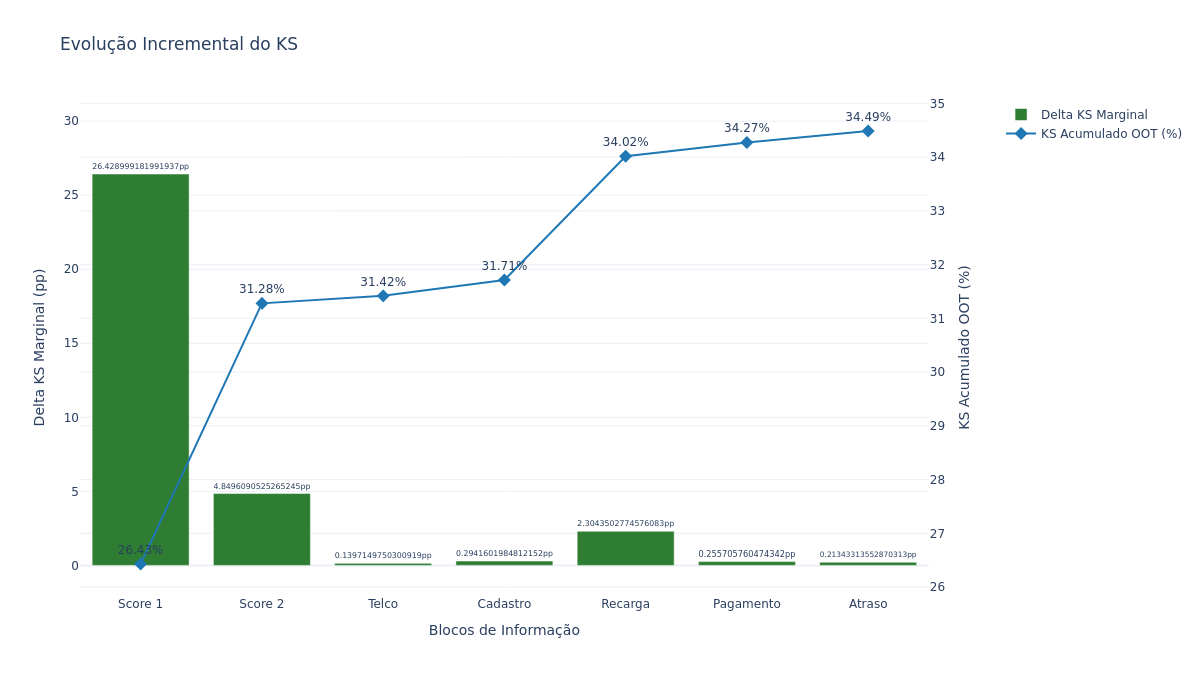

In [14]:
# ---------------------------------------------------------
# KS INCREMENTAL 
# ---------------------------------------------------------

df_inc_results['Etapa_Fmt'] = df_inc_results['Etapa'].str.replace('_', ' ')

fig_inc = make_subplots(specs=[[{"secondary_y": True}]])

colors_inc = [COLORS['good'] if d > 0 else COLORS['bad'] for d in df_inc_results['Delta_KS']]
fig_inc.add_trace(go.Bar(x=df_inc_results['Etapa_Fmt'], y=df_inc_results['Delta_KS'], name='Delta KS Marginal', 
                         marker_color=colors_inc, texttemplate='%{y:+.2f}pp', textposition='outside'), secondary_y=False)

fig_inc.add_trace(go.Scatter(x=df_inc_results['Etapa_Fmt'], y=df_inc_results['KS_OOT'], mode='lines+markers+text', 
                             name='KS Acumulado OOT (%)', marker=dict(symbol='diamond', size=10, color='#1f77b4'),
                             text=df_inc_results['KS_OOT'].apply(lambda x: f'{x:.2f}%'), textposition='top center'), secondary_y=True)

fig_inc.update_layout(title='Evolução Incremental do KS', template='plotly_white', height=675, width=1200, xaxis_title="Blocos de Informação")
fig_inc.update_yaxes(title_text="Delta KS Marginal (pp)", secondary_y=False, range=[-2, max(df_inc_results['Delta_KS'])+5])
fig_inc.update_yaxes(title_text="KS Acumulado OOT (%)", secondary_y=True)
fig_inc.write_image(FIGURES_DIR / 'ks_incremental_v1.png', scale=2)
fig_inc.show(renderer='png')

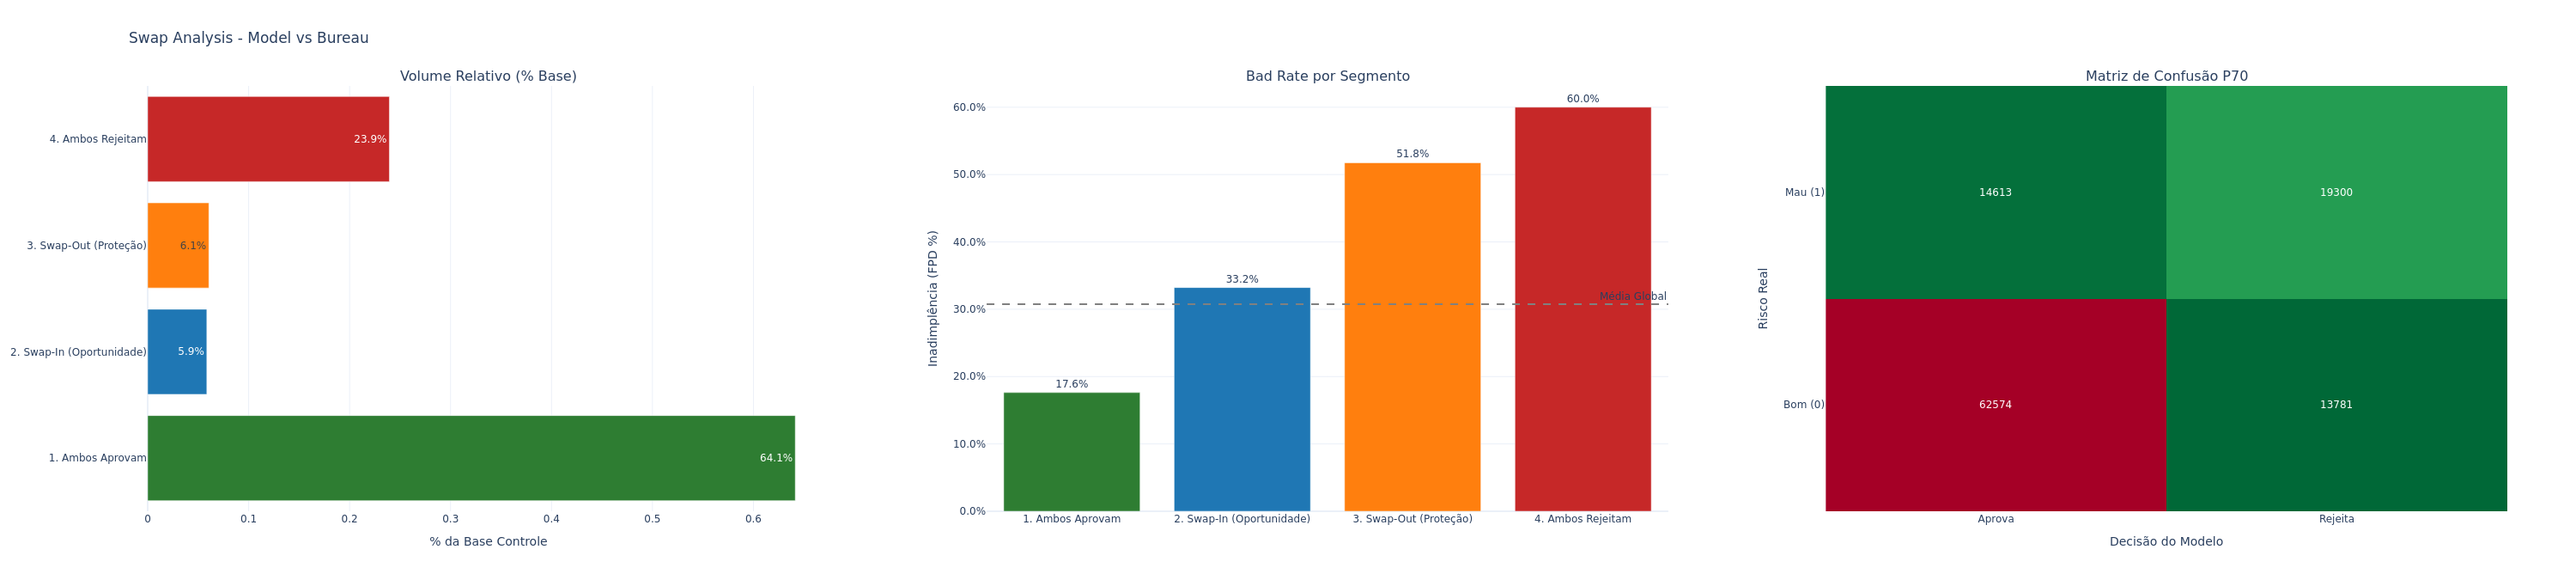

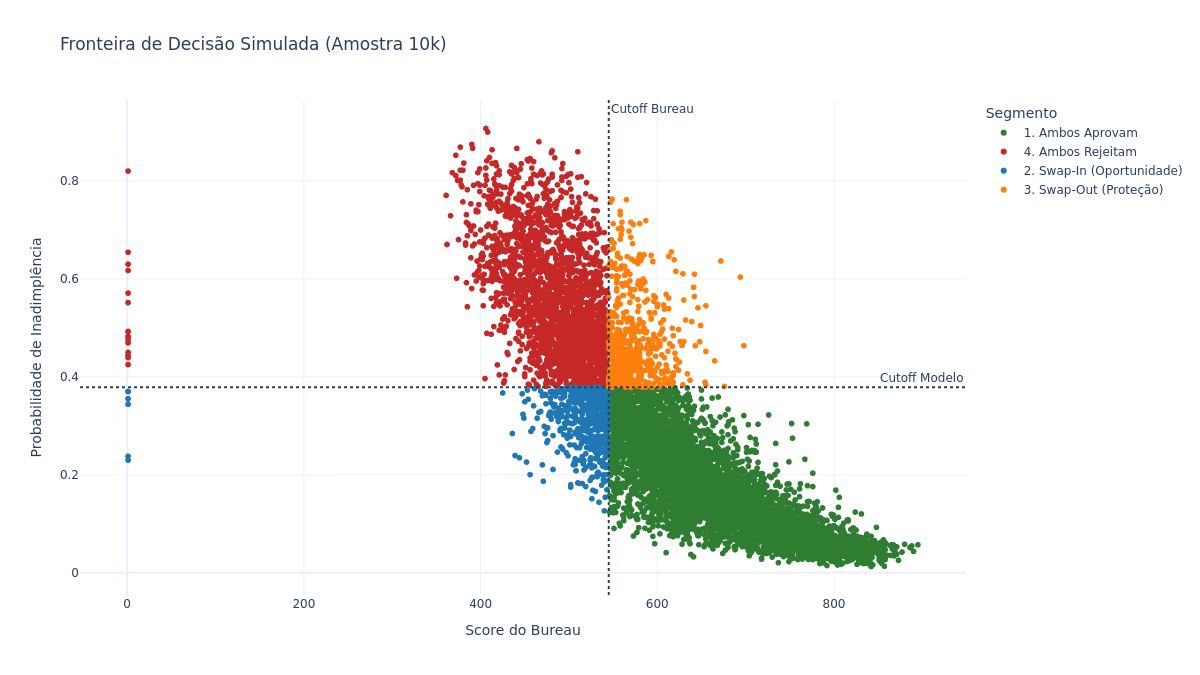

In [15]:
# ---------------------------------------------------------
# ANÁLISE VISUAL DE SWAP-IN / SWAP-OUT (PLOTLY)
# ---------------------------------------------------------

fig_swap = make_subplots(rows=1, cols=3, subplot_titles=('Volume Relativo (% Base)', 'Bad Rate por Segmento', 'Matriz de Confusão P70'))
swap_colors_hex = {'1. Ambos Aprovam': COLORS['good'], '4. Ambos Rejeitam': COLORS['bad'], '2. Swap-In (Oportunidade)': '#1f77b4', '3. Swap-Out (Proteção)': '#ff7f0e'}

# Volume
fig_swap.add_trace(go.Bar(y=swap_summary['categoria'], x=swap_summary['% Base'], orientation='h',
                          marker_color=[swap_colors_hex[c] for c in swap_summary['categoria']],
                          texttemplate='%{x:.1%}', textposition='inside'), row=1, col=1)

# Bad Rate
fig_swap.add_trace(go.Bar(x=swap_summary['categoria'], y=swap_summary['Bad_Rate'],
                          marker_color=[swap_colors_hex[c] for c in swap_summary['categoria']],
                          texttemplate='%{y:.1%}', textposition='outside'), row=1, col=2)
fig_swap.add_hline(y=y_controle.mean(), line_dash='dash', line_color='gray', annotation_text='Média Global', row=1, col=2)

# Heatmap Confusão
cm = confusion_matrix(df_swap['target'], y_pred_modelo)
fig_swap.add_trace(go.Heatmap(z=cm, x=['Aprova', 'Rejeita'], y=['Bom (0)', 'Mau (1)'], colorscale='RdYlGn_r', text=cm, texttemplate="%{text}", showscale=False), row=1, col=3)

fig_swap.update_layout(template='plotly_white', height=675, width=3000, title_text='Swap Analysis - Model vs Bureau', showlegend=False)
fig_swap.update_xaxes(title_text="% da Base Controle", row=1, col=1)
fig_swap.update_yaxes(title_text="Inadimplência (FPD %)", tickformat='.1%', row=1, col=2)
fig_swap.update_xaxes(title_text="Decisão do Modelo", row=1, col=3)
fig_swap.update_yaxes(title_text="Risco Real", row=1, col=3)
fig_swap.write_image(FIGURES_DIR / 'swap_analysis_v1.png', scale=2)
fig_swap.show(renderer='png')

df_swap_plot = df_swap.sample(n=min(10000, len(df_swap)), random_state=42)
fig_scatter = px.scatter(df_swap_plot, x='bur_score_02', y='prob_modelo', color='categoria', color_discrete_map=swap_colors_hex,
                         title='Fronteira de Decisão Simulada (Amostra 10k)', labels={'bur_score_02': 'Score Bureau (Legado)', 'prob_modelo': 'Score Interno (Prob)', 'categoria': 'Segmento'})
fig_scatter.add_vline(x=cutoff_bureau, line_dash="dot", annotation_text="Cutoff Bureau")
fig_scatter.add_hline(y=cutoff_modelo, line_dash="dot", annotation_text="Cutoff Modelo")
fig_scatter.update_layout(template='plotly_white', height=675, width=1200, xaxis_title="Score do Bureau", yaxis_title="Probabilidade de Inadimplência")
fig_scatter.write_image(FIGURES_DIR / 'swap_scatter_v1.png', scale=2)
fig_scatter.show(renderer='png')